In [26]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "liza5757/uiprmd",
    "input.csv"   
)

df.columns = [f"feat_{i}" for i in range(df.shape[1])]

print(f"Shape do DataFrame: {df.shape}")
display(df.head())

/var/folders/19/z0ccr4jn2kz2gqp3drb4cj600000gn/T/ipykernel_66889/1254387750.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Shape do DataFrame: (1422, 100)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95,feat_96,feat_97,feat_98,feat_99
0,-0.065309,-0.418538,2.56967,2,-0.071842,-0.117114,2.51667,2,-0.077804,0.177819,...,2.44895,2,0.236781,-0.472325,2.42335,2,0.266455,-0.410965,2.41400,2
1,-0.065297,-0.418544,2.56975,2,-0.071857,-0.117080,2.51676,2,-0.077860,0.177913,...,2.45184,2,0.237686,-0.474950,2.42791,2,0.263995,-0.404388,2.41996,2
2,-0.065299,-0.418686,2.56996,2,-0.071869,-0.117093,2.51681,2,-0.077879,0.177943,...,2.45650,2,0.233748,-0.471914,2.42121,2,0.265675,-0.411993,2.41274,2
3,-0.065295,-0.418703,2.56999,2,-0.071871,-0.117091,2.51682,2,-0.077893,0.177980,...,2.45339,2,0.234860,-0.477814,2.42666,2,0.266187,-0.410243,2.41519,2
4,-0.065318,-0.418737,2.57014,2,-0.071890,-0.117072,2.51694,2,-0.077911,0.178047,...,2.45896,2,0.235254,-0.477137,2.42411,2,0.266216,-0.412898,2.41219,2


Total de valores nulos: 0


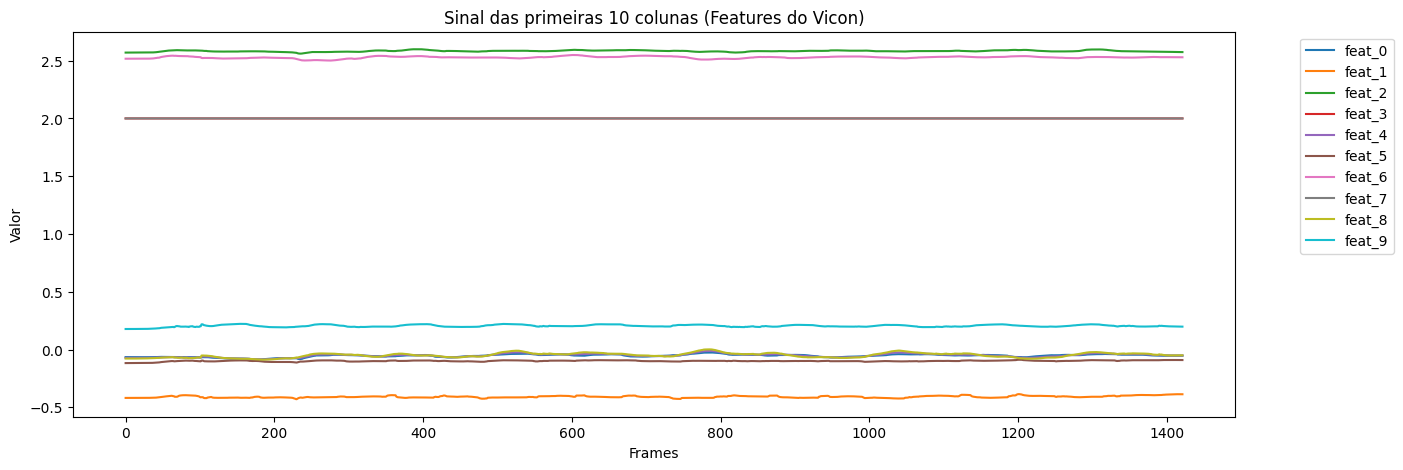

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9
count,1422.000000,1422.000000,1422.000000,1422.0,1422.000000,1422.000000,1422.000000,1422.0,1422.000000,1422.000000
mean,-0.053331,-0.408578,2.582842,2.0,-0.051010,-0.098725,2.528049,2.0,-0.048599,0.204570
std,0.011758,0.008226,0.006228,0.0,0.015156,0.005065,0.009014,0.0,0.019554,0.009258
min,-0.086349,-0.429801,2.560760,2.0,-0.086178,-0.117114,2.500870,2.0,-0.087539,0.177819
25%,-0.061628,-0.415219,2.579143,2.0,-0.062872,-0.100892,2.523020,2.0,-0.066015,0.198529
50%,-0.050847,-0.409108,2.582450,2.0,-0.049417,-0.098575,2.529160,2.0,-0.047297,0.202668
75%,-0.045322,-0.402735,2.586898,2.0,-0.040490,-0.094965,2.533638,2.0,-0.034959,0.212598
max,-0.025371,-0.385850,2.598840,2.0,-0.012108,-0.088200,2.548770,2.0,0.001802,0.222300


In [9]:
import seaborn as sns

null_counts = df.isnull().sum().sum()
print(f"Total de valores nulos: {null_counts}")

df.iloc[:, :10].plot(figsize=(15, 5), title="Sinal das primeiras 10 colunas (Features do Vicon)")
plt.xlabel("Frames")
plt.ylabel("Valor")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

display(df.describe().iloc[:, :10]) 

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno 

marker_names = [f"M{i//3+1}_{['x','y','z'][i%3]}" for i in range(99)]
column_names = marker_names + ["extra_col"] 

df.columns = column_names

print("Primeiras 5 linhas (Amostra de marcadores)")
display(df.iloc[:5, :12].style.background_gradient(cmap='Blues'))

Primeiras 5 linhas (Amostra de marcadores)


,M1_x,M1_y,M1_z,M2_x,M2_y,M2_z,M3_x,M3_y,M3_z,M4_x,M4_y,M4_z
0,-0.065309,-0.418538,2.569670,2,-0.071842,-0.117114,2.516670,2,-0.077804,0.177819,2.450380,2
1,-0.065297,-0.418544,2.569750,2,-0.071857,-0.117080,2.516760,2,-0.077860,0.177913,2.450490,2
2,-0.065299,-0.418686,2.569960,2,-0.071869,-0.117093,2.516810,2,-0.077879,0.177943,2.450500,2
3,-0.065295,-0.418703,2.569990,2,-0.071871,-0.117091,2.516820,2,-0.077893,0.177980,2.450500,2
4,-0.065318,-0.418737,2.570140,2,-0.071890,-0.117072,2.516940,2,-0.077911,0.178047,2.450590,2


<Figure size 1500x400 with 0 Axes>

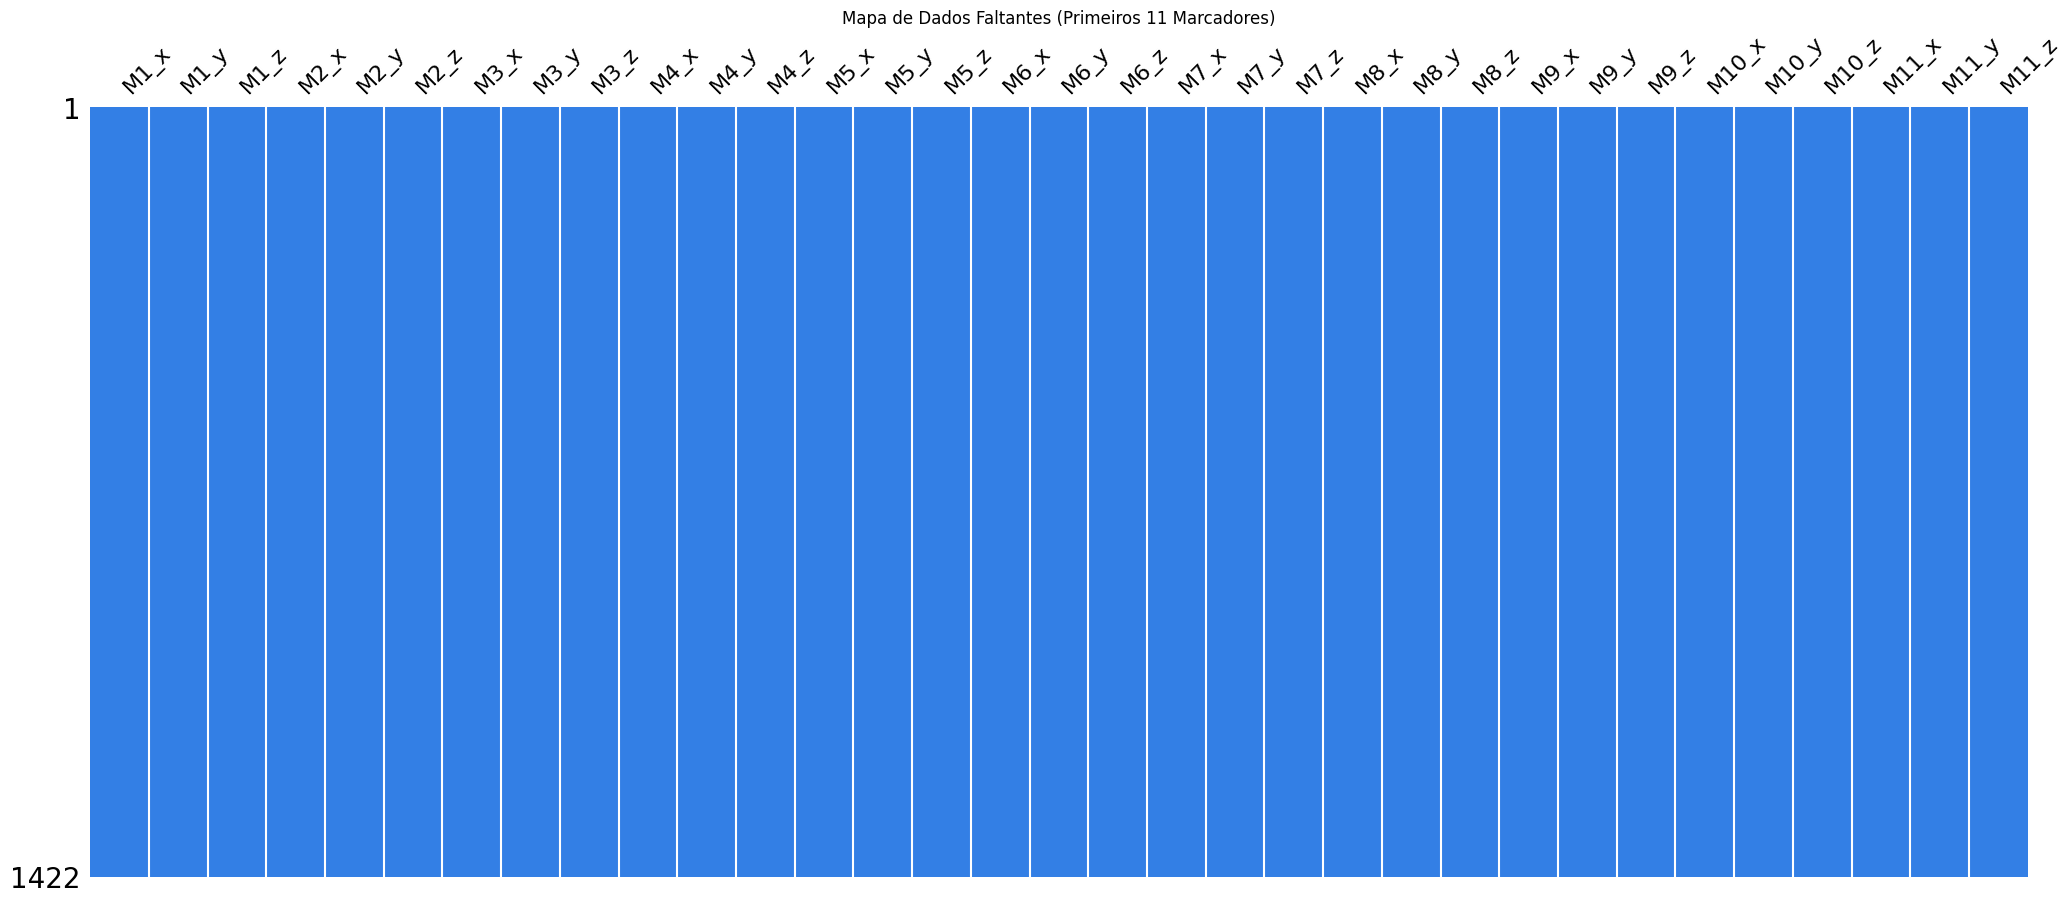

Total de NaNs no arquivo: 0


In [14]:
plt.figure(figsize=(15, 4))
msno.matrix(df.iloc[:, :33], sparkline=False, color=(0.2, 0.5, 0.9))
plt.title("Mapa de Dados Faltantes (Primeiros 11 Marcadores)")
plt.show()

nan_info = df.isnull().sum().sum()
print(f"Total de NaNs no arquivo: {nan_info}")

In [16]:
stats = df.describe().T
stats['range'] = stats['max'] - stats['min']

print("Top 10 Features com maior amplitude de movimento")
display(stats.sort_values(by='range', ascending=False).head(10))

Top 10 Features com maior amplitude de movimento


,count,mean,std,min,25%,50%,75%,max,range
M29_x,1422.0,-0.265782,0.392629,-0.761177,-0.583070,-0.413909,0.033290,0.541872,1.303049
M31_z,1422.0,0.131774,0.400204,-0.655019,-0.188692,0.229706,0.512867,0.609875,1.264894
M33_x,1422.0,0.090142,0.370359,-0.631733,-0.243446,0.151605,0.420438,0.611136,1.242869
M30_y,1422.0,-0.222292,0.358818,-0.722649,-0.538294,-0.337379,0.091568,0.499493,1.222142
M10_y,1422.0,-0.256680,0.359331,-0.710237,-0.557080,-0.400288,0.028683,0.479971,1.190208
M32_y,1422.0,2.124297,0.313713,1.793180,1.869252,2.013505,2.296650,2.960320,1.167140
M15_z,1422.0,0.124006,0.362125,-0.579706,-0.177714,0.203242,0.477913,0.582719,1.162425
M16_y,1422.0,2.139381,0.296149,1.825040,1.894767,2.035875,2.314440,2.964830,1.139790
M33_z,1422.0,2.124350,0.298669,1.800580,1.883242,2.011435,2.243595,2.936830,1.136250
M29_z,1422.0,2.136397,0.336370,1.731300,1.888613,1.996090,2.374437,2.862120,1.130820


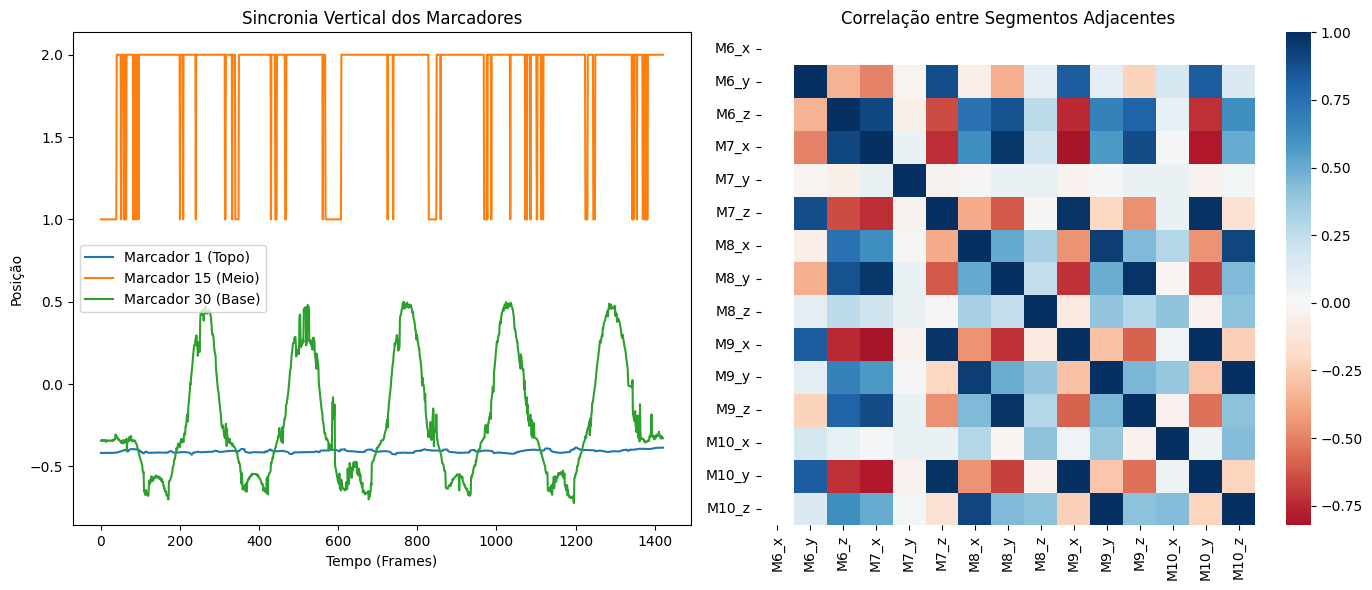

In [17]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df['M1_y'], label='Marcador 1 (Topo)')
plt.plot(df['M15_y'], label='Marcador 15 (Meio)')
plt.plot(df['M30_y'], label='Marcador 30 (Base)')
plt.title("Sincronia Vertical dos Marcadores")
plt.xlabel("Tempo (Frames)")
plt.ylabel("Posição")
plt.legend()

plt.subplot(1, 2, 2)
subset_corr = df.iloc[:, 15:30].corr()
sns.heatmap(subset_corr, cmap='RdBu', center=0)
plt.title("Correlação entre Segmentos Adjacentes")

plt.tight_layout()
plt.show()

In [18]:
marker_labels = [
    "LFHD", "RFHD", "LBHD", "RBHD", "LSHO", "RSHO", "LELB", "RELB", "LWRA", "LWRB", 
    "RWRA", "RWRB", "LASI", "RASI", "LPSI", "RPSI", "LKNE", "RKNE", "LTHI", "RTHI", 
    "LANK", "RANK", "LHEE", "RHEE", "LTOE", "RTOE", "CLAV", "STRN", "C7", "T10", 
    "RBAK", "LTIB", "RTIB"
]

new_cols = []
for marker in marker_labels:
    new_cols.extend([f"{marker}_x", f"{marker}_y", f"{marker}_z"])

if df.shape[1] == 100:
    new_cols.append("label")

df.columns = new_cols

print("Colunas renomeadas com sucesso!")
display(df[['LANK_y', 'RANK_y', 'LHEE_y', 'RHEE_y']].head())

Colunas renomeadas com sucesso!


,LANK_y,RANK_y,LHEE_y,RHEE_y
0,-1.10389,0.009982,2,2.58576
1,-1.10378,0.009999,2,2.58614
2,-1.10441,0.009996,2,2.58621
3,-1.10360,0.010001,2,2.58619
4,-1.10415,0.009985,2,2.58619


In [25]:
traducao_vicon = {
    "LFHD": "Cabeca_Frontal_Esq", "RFHD": "Cabeca_Frontal_Dir",
    "LBHD": "Cabeca_Post_Esq", "RBHD": "Cabeca_Post_Dir",
    "C7": "Vertebra_C7", "T10": "Vertebra_T10",
    "CLAV": "Clavicula", "STRN": "Esterno",
    "LSHO": "Ombro_Esq", "RSHO": "Ombro_Dir",
    "LELB": "Cotovelo_Esq", "RELB": "Cotovelo_Dir",
    "LWRA": "Pulso_A_Esq", "LWRB": "Pulso_B_Esq",
    "RWRA": "Pulso_A_Dir", "RWRB": "Pulso_B_Dir",
    "LASI": "Quadril_Frontal_Esq", "RASI": "Quadril_Frontal_Dir",
    "LPSI": "Quadril_Post_Esq", "RPSI": "Quadril_Post_Dir",
    "LTHI": "Coxa_Esq", "RTHI": "Coxa_Dir",
    "LKNE": "Joelho_Esq", "RKNE": "Joelho_Dir",
    "LTIB": "Tibia_Esq", "RTIB": "Tibia_Dir",
    "LANK": "Tornozelo_Esq", "RANK": "Tornozelo_Dir",
    "LHEE": "Calcanhar_Esq", "RHEE": "Calcanhar_Dir",
    "LTOE": "Ponta_Pe_Esq", "RTOE": "Ponta_Pe_Dir",
    "RBAK": "Costas_Dir"
}

novas_colunas = [f"{traducao_vicon.get(c[:-2], c[:-2])}_{c[-1]}" for c in df.columns]
df.columns = novas_colunas

print("Colunas traduzidas para português:")
display(df.columns[:12])

Colunas traduzidas para português:


Index(['Cabeca_Frontal_Esq_x', 'Cabeca_Frontal_Esq_y', 'Cabeca_Frontal_Esq_z',
       'Cabeca_Frontal_Dir_x', 'Cabeca_Frontal_Dir_y', 'Cabeca_Frontal_Dir_z',
       'Cabeca_Post_Esq_x', 'Cabeca_Post_Esq_y', 'Cabeca_Post_Esq_z',
       'Cabeca_Post_Dir_x', 'Cabeca_Post_Dir_y', 'Cabeca_Post_Dir_z'],
      dtype='object')